# 1 Project Setup: Instacart Market Basket Analysis

## Data Loading and Schema Understanding

This notebook performs the initial data ingestion and structural audit of the Instacart Online Grocery Shopping dataset (6 relational tables: orders, order_products__prior, order_products__train, products, aisles, departments), ahead of exploratory data analysis (EDA) and Market Basket Analysis (MBA).

### Objectives
- Load all Instacart source tables
- Inspect row/column structure
- Understand how the tables relate to each other (shared keys: `order_id`, `product_id`, `aisle_id`, `department_id`)
- Identify the grain of each table
- Validate data types, missing values, duplicates, and categorical distributions
- Prepare a clean, well-understood foundation for EDA and Market Basket Analysis

## 1.1 Import Libraries and Load Datasets

### Objective
Import the required libraries, configure display settings for readability, and load all six raw Instacart CSV files into memory. Datasets are stored in a dictionary (`datasets`) so that later steps can iterate over every table without repeating code.

In [1]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
#Display settings for better visualization
# ==========================================
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:,.2f}'.format)
print("Libraries imported successfully.")

# ==========================================
# File paths to the raw datasets
# ==========================================
orders_path = "../data/raw/orders.csv"
prior_path = "../data/raw/order_products__prior.csv"
train_path = "../data/raw/order_products__train.csv"
products_path = "../data/raw/products.csv"
aisles_path = "../data/raw/aisles.csv"
departments_path = "../data/raw/departments.csv"

# ==========================================
#Load all sources tables
# ==========================================
orders = pd.read_csv(orders_path)
order_products_prior = pd.read_csv(prior_path)
order_products_train = pd.read_csv(train_path)
products = pd.read_csv(products_path)
aisles = pd.read_csv(aisles_path)
departments = pd.read_csv(departments_path)

#==================================================================
# Store datasets in a dictionary for iteration across the notebook
#==================================================================
datasets = {
    "Orders": orders,
    "Order Products Prior": order_products_prior,
    "Order Products Train": order_products_train,
    "Products": products,
    "Aisles": aisles,
    "Departments": departments
}
print("All Datasets loaded successfully.")


Libraries imported successfully.
All Datasets loaded successfully.


# 2 Data Understanding and Quality Assessment

## 2.1 Dataset Preview

### Objective
Preview the first few rows of each dataset to sanity-check the data visually before running deeper checks.

In [2]:
#==========================================
#Preview top rows of each dataset
#==========================================

for name, df in datasets.items():
    print(f"preview of {name}")
    display(df.head())

preview of Orders


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.00
2,473747,1,prior,3,3,12,21.00
3,2254736,1,prior,4,4,7,29.00
4,431534,1,prior,5,4,15,28.00


preview of Order Products Prior


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


preview of Order Products Train


...

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


preview of Aisles


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


preview of Departments


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


### Observation
- Row-level content matches the expected schema for each table (e.g. `orders` shows one row per order with sequencing fields like `order_number` and `days_since_prior_order`).
- `eval_set` in `orders` confirms the prior/train/test split used by Instacart's original competition design.

## 2.2 Dataset Shape

### Objective
Check the number of rows and columns in each dataset to understand its scale and grain before further inspection.

In [3]:
#==========================================
#shape of the each datasets
#==========================================
for name, df in datasets.items():
    print(f"{name} shape: {df.shape}")

Orders shape: (3421083, 7)
Order Products Prior shape: (32434489, 4)
Order Products Train shape: (1384617, 4)
Products shape: (49688, 4)
Aisles shape: (134, 2)
Departments shape: (21, 2)


### Observation
- `order_products_prior` (32.4M rows) is by far the largest table, representing the full history of prior purchases, while `order_products_train` (1.4M rows) is a much smaller labeled subset held out for prediction tasks.
- `orders` (3.42M rows) sits at the order grain, one row per order.
- `products`, `aisles`, and `departments` are small lookup/dimension tables (49,688 / 134 / 21 rows respectively), each keyed by their own ID.

## 2.3 Column Names

### Objective
Inspect the column structure of each dataset to identify the join keys that link the tables together and confirm the grain of each one.

In [4]:
# ==========================================
#Columns in each dataset
# ==========================================

for name, df in datasets.items():
    print(f"Columns in {name}: {list(df.columns)}\n")


Columns in Orders: ['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']

Columns in Order Products Prior: ['order_id', 'product_id', 'add_to_cart_order', 'reordered']

Columns in Order Products Train: ['order_id', 'product_id', 'add_to_cart_order', 'reordered']

Columns in Products: ['product_id', 'product_name', 'aisle_id', 'department_id']

Columns in Aisles: ['aisle_id', 'aisle']

Columns in Departments: ['department_id', 'department']



### Observation
- `order_id` links `orders` to `order_products_prior` / `order_products_train`.
- `product_id` links the order-product tables to `products`.
- `aisle_id` / `department_id` appear in `products`, `aisles`, `departments` → link products to their category hierarchy.
- This confirms a classic star-schema layout: `orders` and `order_products_*` are fact tables, while `products`, `aisles`, and `departments` are dimension tables.

## 2.4 Data Types

### Objective
Inspect the data type of each column across all datasets to verify that every variable is stored in the correct format before performing analysis.

In [5]:
# ==========================================
#Inspect the data types of each dataset
# ==========================================
for name, df in datasets.items():
    print(f"{name} data types:")
    print(df.dtypes,"\n")

Orders data types:
order_id                    int64
user_id                     int64
eval_set                      str
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
dtype: object 

Order Products Prior data types:
order_id             int64
product_id           int64
add_to_cart_order    int64
reordered            int64
dtype: object 

Order Products Train data types:
order_id             int64
product_id           int64
add_to_cart_order    int64
reordered            int64
dtype: object 

Products data types:
product_id       int64
product_name       str
aisle_id         int64
department_id    int64
dtype: object 

Aisles data types:
aisle_id    int64
aisle         str
dtype: object 

Departments data types:
department_id    int64
department         str
dtype: object 



### Observation
- Most columns contain whole numerical values such as identifiers and order-related information.
- The `days_since_prior_order` column may contain decimal values or missing (`NaN`) values.
- Text-based columns include `eval_set`, `product_name`, `aisle`, and `department`.
- No obvious data type inconsistencies were observed at this stage.

## 2.5 Grain, Primary Keys & Foreign Keys

### Objective

Identify the grain (level of detail), primary keys (PK), and foreign keys (FK) of each dataset to understand how the tables are related before performing joins.

| Dataset              | Grain (One Row = ...)              | Primary Key (PK)                            | Foreign Key (FK)            |
| -------------------- | ---------------------------------- | ------------------------------------------- | --------------------------- |
| Orders               | One order                          | `order_id`                                  | `user_id`                   |
| Order Products Prior | One product within one prior order | (`order_id`, `product_id`) *(Composite PK)* | `order_id`, `product_id`    |
| Order Products Train | One product within one train order | (`order_id`, `product_id`) *(Composite PK)* | `order_id`, `product_id`    |
| Products             | One product                        | `product_id`                                | `aisle_id`, `department_id` |
| Aisles               | One aisle                          | `aisle_id`                                  | —                           |
| Departments          | One department                     | `department_id`                             | —                           |

## 2.6 Missing Values

### Objective

Identify missing values across all datasets to evaluate data quality and determine whether any missing values require cleaning or represent meaningful business information.

In [6]:
#==========================================
# Missing Values Analysis
#==========================================

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.isnull().sum())


Orders
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

Order Products Prior
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

Order Products Train
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

Products
product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64

Aisles
aisle_id    0
aisle       0
dtype: int64

Departments
department_id    0
department       0
dtype: int64


### Observation

- Only the `days_since_prior_order` column in the **Orders** dataset contains missing values (206,209 records, approximately **6.03%**).
- All other columns across the six datasets contain no missing values.
- The missing values appear to be limited to a single business-related attribute rather than indicating widespread data quality issues.

## 2.7 Duplicate Rows

### Objective

Identify duplicate records across all datasets to ensure data integrity before performing analysis.

In [7]:
#==========================================
# Duplicate Analysis
#==========================================

for name, df in datasets.items():
    duplicate_count = df.duplicated().sum()
    duplicate_percentage = df.duplicated().mean() * 100


    print(f"\n{name}")
    print(f"Duplicate Rows: {duplicate_count}")
    print(f"Duplicate Percentage: {duplicate_percentage:.2f}%")


Orders
Duplicate Rows: 0
Duplicate Percentage: 0.00%

Order Products Prior
Duplicate Rows: 0
Duplicate Percentage: 0.00%

Order Products Train
Duplicate Rows: 0
Duplicate Percentage: 0.00%

Products
Duplicate Rows: 0
Duplicate Percentage: 0.00%

Aisles
Duplicate Rows: 0
Duplicate Percentage: 0.00%

Departments
Duplicate Rows: 0
Duplicate Percentage: 0.00%


### Observation

- No duplicate rows were found in any of the six datasets.
- This indicates that there are no exact duplicate records at the row level.
- Further validation is still required to check for missing values, invalid values, and relationship consistency between tables.

## 2.8 Categorical Validation

### Objective

Explore categorical columns to understand the distribution of categories and validate expected values.

In [8]:
#==========================================
# Categorical Value Validation
#==========================================

categorical_columns = {
    "Orders - eval_set": orders["eval_set"],
    "Order Products Prior - reordered": order_products_prior["reordered"],
    "Order Products Train - reordered": order_products_train["reordered"]
}

for name, column in categorical_columns.items():
    print("=" * 50)
    print(name)
    print("=" * 50)
    print(column.value_counts())
    print()

Orders - eval_set
eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64

Order Products Prior - reordered
reordered
1    19126536
0    13307953
Name: count, dtype: int64

Order Products Train - reordered
reordered
1    828824
0    555793
Name: count, dtype: int64



### Observation
- The `eval_set` column contains the expected categories: `prior`, `train`, and `test`.
- The `prior` dataset contains the majority of orders, indicating that most records represent customers' historical purchases.
- The `reordered` column contains only valid binary values (`0` and `1`) in both prior and train datasets.
- Reordered products (`1`) occur more frequently than non-reordered products (`0`), suggesting that customers often repurchase previously bought items.

## 2.9 Dataset Information

### Objective

Inspect the structure of each dataset, including the number of rows, columns, data types, non-null values, and memory usage.

In [9]:
for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print("=" * 60)
    df.info()
    print()

Orders
<class 'pandas.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                str    
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), str(1)
memory usage: 182.7 MB

Order Products Prior
<class 'pandas.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 989.8 MB

Order Products Train
<class 'pandas.DataFrame'>
RangeIndex: 1384617 entries, 0 to 1384616
Data columns (total 4 columns):
 #   Column             Non-Nul


### Observation

- Dataset structures were successfully verified.
- Most columns have appropriate data types (`int64` and `object`/`str`).
- Only `days_since_prior_order` contains missing values, while all other columns are complete.
- Memory usage is reasonable for the size of each dataset.

## 2.10 Statistical Summary

### Objective

Generate summary statistics for numerical columns to understand their distribution, central tendency, and variability.

In [10]:
for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print("=" * 60)
    display(df.describe())
    print()

Orders


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,"3,421,083.00","3,421,083.00","3,421,083.00","3,421,083.00","3,421,083.00","3,214,874.00"
mean,"1,710,542.00","102,978.21",17.15,2.78,13.45,11.11
std,"987,581.74","59,533.72",17.73,2.05,4.23,9.21
min,1.00,1.00,1.00,0.00,0.00,0.00
25%,"855,271.50","51,394.00",5.00,1.00,10.00,4.00
50%,"1,710,542.00","102,689.00",11.00,3.00,13.00,7.00
75%,"2,565,812.50","154,385.00",23.00,5.00,16.00,15.00
max,"3,421,083.00","206,209.00",100.00,6.00,23.00,30.00



Order Products Prior


,order_id,product_id,add_to_cart_order,reordered
count,"32,434,489.00","32,434,489.00","32,434,489.00","32,434,489.00"
mean,"1,710,748.52","25,576.34",8.35,0.59
std,"987,300.70","14,096.69",7.13,0.49
min,2.00,1.00,1.00,0.00
25%,"855,943.00","13,530.00",3.00,0.00
50%,"1,711,048.00","25,256.00",6.00,1.00
75%,"2,565,514.00","37,935.00",11.00,1.00
max,"3,421,083.00","49,688.00",145.00,1.00



Order Products Train


...

,product_id,aisle_id,department_id
count,"49,688.00","49,688.00","49,688.00"
mean,"24,844.50",67.77,11.73
std,"14,343.83",38.32,5.85
min,1.00,1.00,1.00
25%,"12,422.75",35.00,7.00
50%,"24,844.50",69.00,13.00
75%,"37,266.25",100.00,17.00
max,"49,688.00",134.00,21.00



Aisles


,aisle_id
count,134.00
mean,67.50
std,38.83
min,1.00
25%,34.25
50%,67.50
75%,100.75
max,134.00



Departments


,department_id
count,21.00
mean,11.00
std,6.20
min,1.00
25%,6.00
50%,11.00
75%,16.00
max,21.00


### Observation

- The statistical summary confirms that all numerical columns contain valid values.
- Customers placed an average of approximately 17 orders.
- Orders are typically placed around 1 PM (`order_hour_of_day` mean ≈ 13.45).
- Customers reorder after approximately 11 days on average.
- The dataset contains customers with up to 100 orders, indicating varying purchasing behavior.

### Next Steps
With schema, types, missing values, duplicates, and category distributions validated, the notebook is ready to proceed to exploratory data analysis (EDA) and feature engineering for Market Basket Analysis.

## Summary

### Key Findings

- Successfully loaded and validated all six datasets.
- Identified dataset grain, primary keys, and foreign keys.
- Verified that only `days_since_prior_order` contains missing values.
- No duplicate rows were found.
- Validated categorical columns and confirmed expected values.
- Generated statistical summaries to understand the overall data distribution.

### Conclusion

The datasets are well-structured and ready for data cleaning, feature engineering, and business analysis in the next milestone.

# 3 Data Cleaning & Preparation

## 3.1 Validate Primary Keys

### Objective

Verify that the identified primary keys uniquely identify each record and confirm the integrity of relationships before merging datasets.

### Observation

- `order_id` is unique in the Orders dataset and `product_id` is unique in the Products dataset.
- No duplicate combinations of (`order_id`, `product_id`) were found in either the Prior or Train datasets.
- The primary keys and composite primary keys are valid, indicating that the datasets maintain referential integrity and are safe to use for joins.

In [11]:
# Orders primary key
print("Orders - order_id unique:",
      orders["order_id"].is_unique)

# Products primary key
print("Products - product_id unique:",
      products["product_id"].is_unique)

# Composite primary key (Prior)
prior_duplicates = order_products_prior.duplicated(
    subset=["order_id", "product_id"]
).sum()

print("Prior composite PK duplicates:", prior_duplicates)

# Composite primary key (Train)
train_duplicates = order_products_train.duplicated(
    subset=["order_id", "product_id"]
).sum()

print("Train composite PK duplicates:", train_duplicates)

Orders - order_id unique: True
Products - product_id unique: True
Prior composite PK duplicates: 0
Train composite PK duplicates: 0


## 3.2 Missing Value Treatment

### Objective

Evaluate the identified missing values and determine the appropriate treatment based on their business meaning to preserve data integrity.

### Observation

- Missing values exist only in the `days_since_prior_order` column.
- These missing values represent customers' first orders, where no previous order exists.
- Since the missing values are meaningful and expected, they were retained without imputation or removal.

### Decision

No changes were made to the missing values because they represent valid business information rather than data quality issues. Filling or removing these values would distort customer behavior analysis.

## 3.3 Create Analysis-Ready Dataset

### Objective

Combine the transactional and reference datasets using their primary and foreign key relationships to create a single analysis-ready dataset for customer behavior and market basket analysis.

### Observation

- Successfully merged the `Order Products Prior` and `Orders` datasets using `order_id`.
- The row count remained unchanged, confirming that no records were lost or duplicated during the merge.
- Order-level information has been successfully added to each product transaction.

In [12]:
#==========================================
# Merge prior order products with orders
#==========================================
instacart_df = order_products_prior.merge(
    orders,
    on="order_id",
    how="left"
)

print("Merged Shape:", instacart_df.shape)

print("Expected Rows:", len(order_products_prior))
print("Actual Rows:", len(instacart_df))
display(instacart_df.head())

Merged Shape: (32434489, 10)
Expected Rows: 32434489
Actual Rows: 32434489


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2,33120,1,1,202279,prior,3,5,9,8.00
1,2,28985,2,1,202279,prior,3,5,9,8.00
2,2,9327,3,0,202279,prior,3,5,9,8.00
3,2,45918,4,1,202279,prior,3,5,9,8.00
4,2,30035,5,0,202279,prior,3,5,9,8.00


### Observation

- Successfully merged the Products dataset using `product_id`.
- Product names, aisle IDs, and department IDs were added to each transaction.
- The row count remained unchanged, confirming that the merge preserved all transaction records.

In [13]:
#==========================================
# Merge product information
#==========================================
instacart_df = instacart_df.merge(
    products,
    on="product_id",
    how="left"
)

print("Merged Shape:", instacart_df.shape)
print("Expected Rows:", len(order_products_prior))
print("Actual Rows:", len(instacart_df))
display(instacart_df.head())

Merged Shape: (32434489, 13)
Expected Rows: 32434489
Actual Rows: 32434489


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id
0,2,33120,1,1,202279,prior,3,5,9,8.00,Organic Egg Whites,86,16
1,2,28985,2,1,202279,prior,3,5,9,8.00,Michigan Organic Kale,83,4
2,2,9327,3,0,202279,prior,3,5,9,8.00,Garlic Powder,104,13
3,2,45918,4,1,202279,prior,3,5,9,8.00,Coconut Butter,19,13
4,2,30035,5,0,202279,prior,3,5,9,8.00,Natural Sweetener,17,13


In [14]:
#==========================================
# Merge aisle information
#==========================================
instacart_df = instacart_df.merge(
    aisles,
    on="aisle_id",
    how="left"
)

print("Merged Shape:", instacart_df.shape)
display(instacart_df.head())

Merged Shape: (32434489, 14)


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle
0,2,33120,1,1,202279,prior,3,5,9,8.00,Organic Egg Whites,86,16,eggs
1,2,28985,2,1,202279,prior,3,5,9,8.00,Michigan Organic Kale,83,4,fresh vegetables
2,2,9327,3,0,202279,prior,3,5,9,8.00,Garlic Powder,104,13,spices seasonings
3,2,45918,4,1,202279,prior,3,5,9,8.00,Coconut Butter,19,13,oils vinegars
4,2,30035,5,0,202279,prior,3,5,9,8.00,Natural Sweetener,17,13,baking ingredients


In [15]:
#==========================================
# Merge department information
#==========================================
instacart_df = instacart_df.merge(
    departments,
    on="department_id",
    how="left"
)
print("Merged Shape:", instacart_df.shape)
display(instacart_df.head())

Merged Shape: (32434489, 15)


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.00,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.00,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.00,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,8.00,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,8.00,Natural Sweetener,17,13,baking ingredients,pantry


### Observation

- Successfully merged the Orders, Products, Aisles, and Departments datasets with the transaction data.
- The final analysis-ready dataset contains **32,434,489 rows** and **15 columns**.
- Row count remained unchanged after every merge, confirming that all joins preserved the transactional records.
- The dataset now includes customer, order, product, aisle, and department information required for business analysis.

## 3.4 Post-Merge Validation

### Objective

Validate the merged dataset to ensure no records were lost or duplicated and verify that key descriptive fields were successfully populated after all joins.

In [16]:
print(instacart_df.shape)

print("\nMissing Values:")
print(instacart_df[
    ["product_name", "aisle", "department"]
].isnull().sum())

(32434489, 15)

Missing Values:
product_name    0
aisle           0
department      0
dtype: int64


### Observation

- The merged dataset maintained the expected number of rows.
- No missing values were introduced in the descriptive columns (`product_name`, `aisle`, and `department`).
- The dataset passed all validation checks and is ready for exploratory analysis.

# 4 Exploratory Data Analysis (EDA)
Total orders: 3214874
Unique Customer IDs: 206209
Unique Product IDs: 49677

### 4.1 Dataset Overview
#### Objective
Generate key business metrics to understand the overall scale of the Instacart dataset before performing detailed analysis.

In [17]:
print("Total orders:", orders["order_id"].count())
print("Unique Customer IDs:", instacart_df["user_id"].nunique())
print("Unique Product IDs:", instacart_df["product_id"].nunique())
reordered_rate = instacart_df["reordered"].mean()*100
print(f"Reordered Rate: {reordered_rate:.2f}%")


Total orders: 3421083
Unique Customer IDs: 206209
Unique Product IDs: 49677
Reordered Rate: 58.97%


#### Observation

- The dataset contains over **3.4 million orders** from **206,209 customers**.
- Customers purchased approximately **49.7K unique products** across **21 departments**.
- The overall reorder rate is **58.97%**, indicating that a majority of purchased products are repeat purchases.
- This suggests strong customer retention and recurring purchasing behavior on the Instacart platform.

## 4.2 Product Analysis

#### Objective

Identify the most purchased products and understand customer purchasing preferences by analyzing product popularity.

product_name
Organic Whole Milk        137905
Limes                     140627
Strawberries              142951
Large Lemon               152657
Organic Avocado           176815
Organic Hass Avocado      213584
Organic Baby Spinach      241921
Organic Strawberries      264683
Bag of Organic Bananas    379450
Banana                    472565
Name: count, dtype: int64

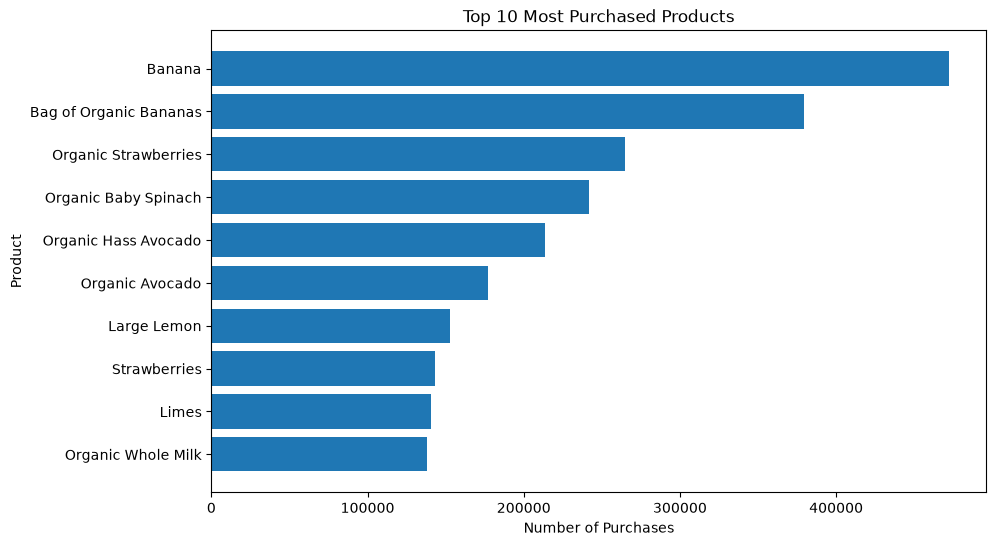

In [18]:
top_products = (
    instacart_df["product_name"]
    .value_counts()
    .head(10)
    .sort_values()
)

display(top_products)
plt.figure(figsize=(10,6))

plt.barh(top_products.index, top_products.values)

plt.title("Top 10 Most Purchased Products")
plt.xlabel("Number of Purchases")
plt.ylabel("Product")

plt.show()

#### Observation

- **Banana** is the most purchased product, making it the highest-demand item in the dataset.
- Fresh produce dominates the top-selling products, with items such as **Bag of Organic Bananas**, **Organic Strawberries**, and **Organic Baby Spinach** appearing among the most purchased.
- Most of the top 10 products are fruits and vegetables, indicating strong customer preference for fresh and organic grocery items.
- These products are likely key revenue drivers and should be prioritized for inventory planning and stock availability.

### 4.2.1 Department Analysis

#### Objective

Analyze product purchases across departments to identify the most popular product categories and understand customer buying preferences.

In [ ]:
top_departments = (
    instacart_df["department"]
    .value_counts()
    .head(10)
)
display(top_departments)

department
produce            9479291
dairy eggs         5414016
snacks             2887550
beverages          2690129
frozen             2236432
pantry             1875577
bakery             1176787
canned goods       1068058
deli               1051249
dry goods pasta     866627
Name: count, dtype: int64

#### Observation

- The **Produce** department recorded the highest number of purchases, making it the most popular department among customers.
- **Dairy Eggs** and **Snacks** also rank among the top purchased departments, indicating strong demand for everyday grocery essentials.
- The majority of purchases are concentrated in a few major departments, suggesting that customers primarily buy fresh produce and frequently consumed food items.
- These findings can help Instacart prioritize inventory management, supplier coordination, and promotional campaigns for high-demand departments.

### 4.2.2 Aisle Analysis

#### Objective

Identify the most frequently purchased aisles to understand customer shopping preferences at a more detailed category level.

aisle
fresh fruits                     3642188
fresh vegetables                 3418021
packaged vegetables fruits       1765313
yogurt                           1452343
packaged cheese                   979763
milk                              891015
water seltzer sparkling water     841533
chips pretzels                    722470
soy lactosefree                   638253
bread                             584834
Name: count, dtype: int64

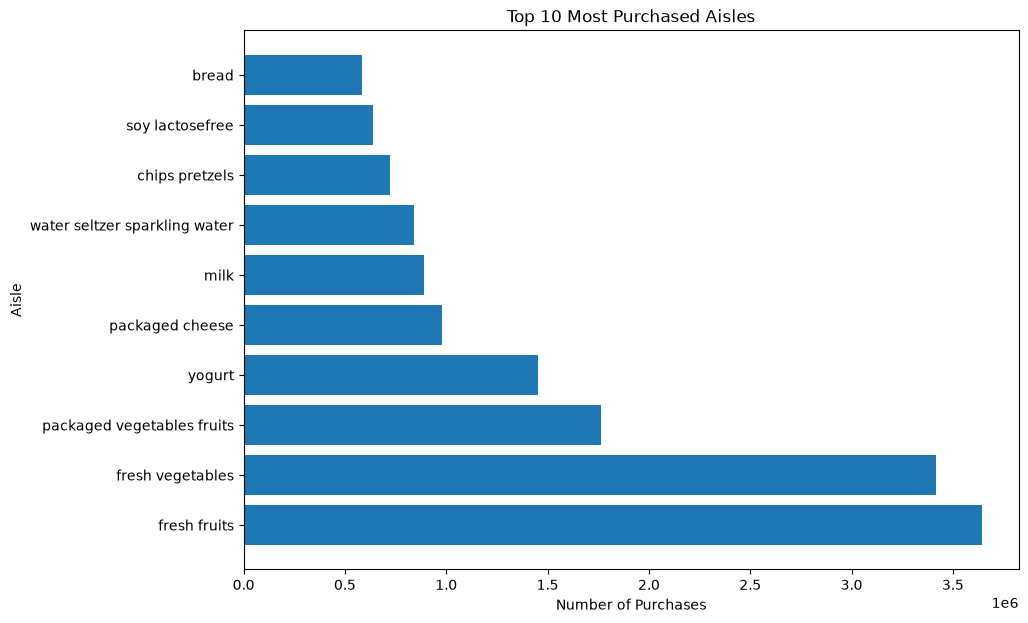

In [34]:
top_aisles=(
    instacart_df["aisle"]
    .value_counts()
    .head(10)
)
display(top_aisles)

plt.figure(figsize=(10,7))

plt.barh(top_aisles.index, top_aisles.values)

plt.title("Top 10 Most Purchased Aisles")
plt.xlabel("Number of Purchases")
plt.ylabel("Aisle")

plt.show()

#### Observation

- The **Fresh Fruits** aisle recorded the highest number of purchases, making it the most popular shopping aisle.
- Other top-performing aisles primarily consist of fresh produce, dairy, and commonly purchased grocery essentials.
- Customer purchases are concentrated in a small number of high-demand aisles, indicating consistent buying patterns for everyday household and fresh food items.
- These insights can help optimize product placement, inventory management, and promotional strategies for the most frequently visited aisles.

### 4.2.3 Reorder Analysis

#### Objective

Analyze customer reorder behavior to identify frequently repurchased products and measure overall customer retention through reorder patterns.

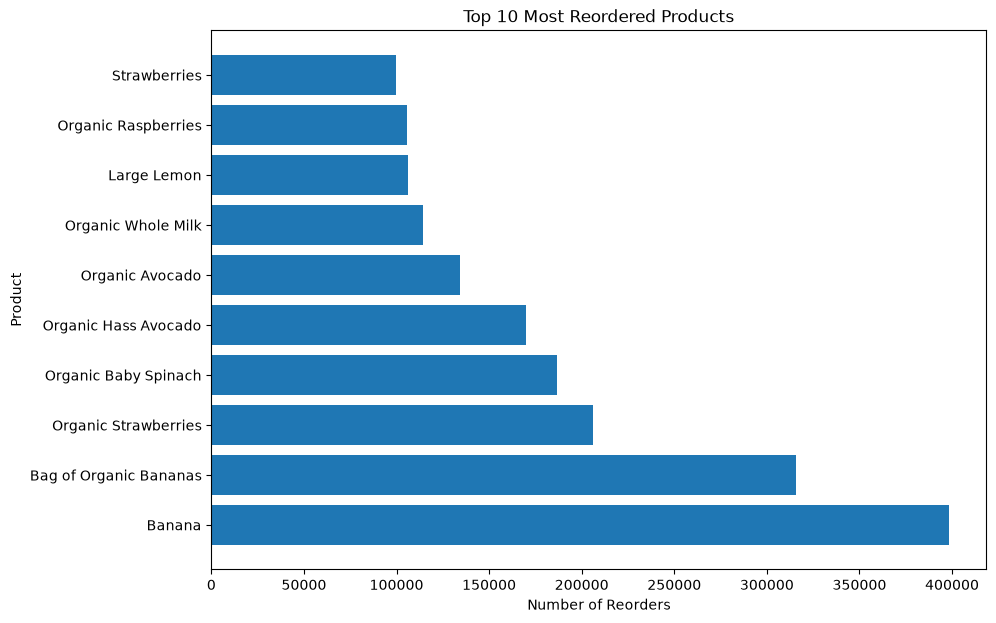

In [21]:
reordered_df = instacart_df[instacart_df["reordered"]==1]
top_reordered_products = (
    reordered_df["product_name"].value_counts().head(10)
)
plt.figure(figsize=(10,7))

plt.barh(
    top_reordered_products.index,
    top_reordered_products.values
)

plt.title("Top 10 Most Reordered Products")
plt.xlabel("Number of Reorders")
plt.ylabel("Product")

plt.show()

#### Observation

- **Banana** is the most frequently reordered product, indicating strong customer loyalty and repeat purchasing behavior.
- Fresh fruits and organic products dominate the list of most reordered items, suggesting that customers regularly repurchase essential grocery products.
- Frequently reordered products represent stable customer demand and should be prioritized for inventory management and stock replenishment.
- These products are strong candidates for subscription services, personalized recommendations, and promotional campaigns due to their high repeat purchase behavior.

### 4.2.4 Reorder Rate by Product

#### Objective

Calculate the reorder rate for each product to identify products with the strongest customer loyalty and repeat purchase behavior.

product_name
Chocolate Love Bar                                            92.08
Maca Buttercups                                               90.00
Benchbreak Chardonnay                                         89.19
Fragrance Free Clay with Natural Odor Eliminator Cat Litter   87.60
Thousand Island Salad Snax                                    87.50
Real2 Alkalized Water 500 ml                                  86.25
Half And Half Ultra Pasteurized                               86.17
Whole Organic Omega 3 Milk                                    86.02
Organic Lactose Free Whole Milk                               85.90
Organic Homogenized Whole Milk                                85.77
Name: count, dtype: float64

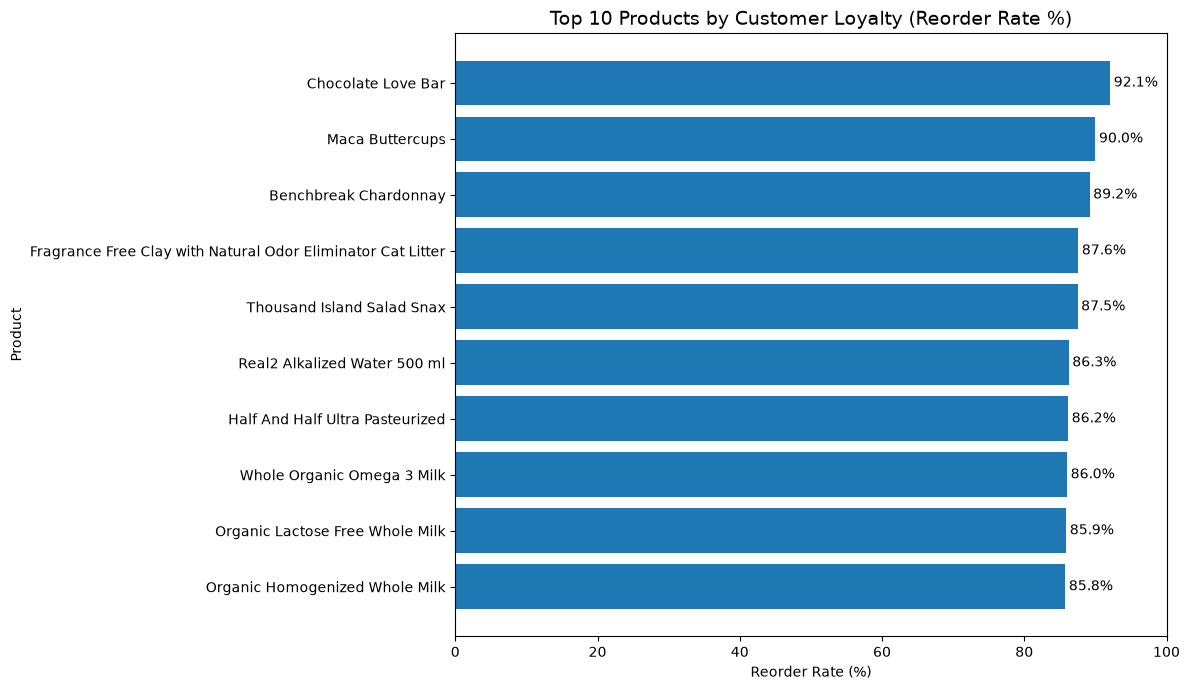

In [22]:
total_purchases = instacart_df["product_name"].value_counts()

reordered_purchases = reordered_df["product_name"].value_counts()

valid_products = total_purchases[total_purchases >= 100]

reorder_rate = (
    reordered_purchases.loc[valid_products.index] / valid_products
) * 100

reorder_rate = reorder_rate.fillna(0).sort_values(ascending=False)
top_reorder_rate = reorder_rate.head(10)

display(top_reorder_rate.head(10))

plt.figure(figsize=(12,7))

plt.barh(
    top_reorder_rate.index[::-1],
    top_reorder_rate.values[::-1]
)

plt.title("Top 10 Products by Customer Loyalty (Reorder Rate %)", fontsize=14)
plt.xlabel("Reorder Rate (%)")
plt.ylabel("Product")

# Add percentage labels
for i, value in enumerate(top_reorder_rate.values[::-1]):
    plt.text(
        value + 0.5,
        i,
        f"{value:.1f}%",
        va="center"
    )

plt.xlim(0, 100)

plt.tight_layout()
plt.show()

#### Observation

- The products with the highest reorder rates are not necessarily the most purchased products, but they demonstrate the strongest customer loyalty.
- Several dairy products, beverages, and specialty grocery items achieved reorder rates above **85%**, indicating that customers who purchase these items are highly likely to buy them again.
- Applying a minimum purchase threshold (100 purchases) helped eliminate statistically unreliable products with very low sales volume, making the analysis more meaningful.
- Products with consistently high reorder rates are strong candidates for subscription services, personalized recommendations, and inventory prioritization due to their repeat purchase behavior.

## 4.4 Customer Order Behavior Analysis

### 4.4.1 Customer Analysis

#### Objective

Analyze customer purchasing behavior by examining the number of orders placed by each customer and identifying ordering patterns across the customer base.


In [23]:
#============================================
# Order per customer
#============================================
customer_orders = orders.groupby("user_id")["order_id"].count()

display(customer_orders.head())

#===========================================
# Customer order statistics
#===========================================
customer_orders = orders.groupby("user_id")["order_id"].count()

average_orders = customer_orders.mean()
customer_orders.describe()

user_id
1    11
2    15
3    13
4     6
5     5
Name: order_id, dtype: int64

count   206,209.00
mean         16.59
std          16.65
min           4.00
25%           6.00
50%          10.00
75%          20.00
max         100.00
Name: order_id, dtype: float64

#### Observation

- A total of **206,209 customers** were analyzed.
- On average, each customer placed approximately **17 orders**.
- Half of all customers placed **10 or fewer orders**, while 75% placed **20 or fewer orders**.
- The most active customer placed **100 orders**, indicating the presence of highly loyal or frequent shoppers.
- Since the mean (16.59) is higher than the median (10), the distribution is positively skewed, suggesting that a small group of high-frequency customers increases the overall average.

### 4.4.1 Products per Order

#### Objective

Analyze how many products customers purchase in each order to understand typical basket sizes and overall shopping behavior.

In [24]:
products_per_order=(
    instacart_df.groupby("order_id")["product_id"]
    .count()
)   
average_products = products_per_order.mean()
median_products =products_per_order.median()
display(products_per_order.describe())

count   3,214,874.00
mean           10.09
std             7.53
min             1.00
25%             5.00
50%             8.00
75%            14.00
max           145.00
Name: product_id, dtype: float64

#### Observation

- A total of **3,214,874 orders** were analyzed.
- Customers purchase an average of **10.09 products per order**, indicating a moderately sized shopping basket.
- The median basket size is **8 products**, meaning that half of all orders contain 8 or fewer products.
- The difference between the mean (10.09) and median (8) suggests the presence of some large orders that increase the average basket size.
- Most orders contain between **5 and 14 products** (25th to 75th percentile), showing that customers generally purchase a moderate number of items in each shopping trip.
- The largest order contains **145 products**, representing an extreme outlier compared to typical customer purchases.

### 4.4.2 Shopping Day Preferences

#### Objective

Analyze customer ordering patterns across different days of the week to identify peak shopping days and understand weekly purchasing behavior.

order_dow
0    557772
1    556705
2    441955
3    412400
4    401212
5    425982
6    418848
Name: order_id, dtype: int64

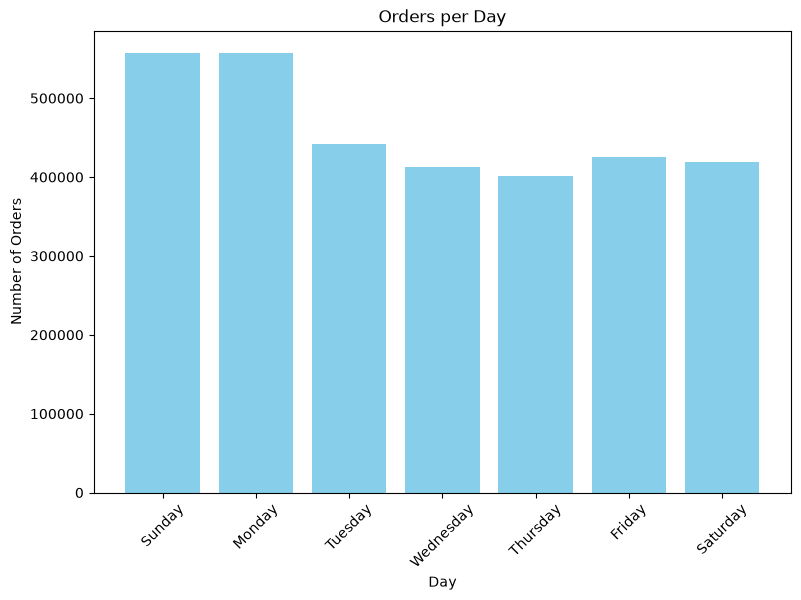

In [25]:
orders_per_day = (instacart_df.groupby("order_dow")["order_id"].nunique())
display(orders_per_day)

day_names = {
    0: "Sunday",
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday"
}

orders_per_day_plot = orders_per_day.copy()
orders_per_day_plot.index = orders_per_day_plot.index.map(day_names)
plt.figure(figsize=(9,6))
plt.bar(orders_per_day_plot.index, orders_per_day_plot.values, color='skyblue')
plt.title("Orders per Day")
plt.xlabel("Day")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()


#### Observation

- Customer ordering activity is highest on **Day 0 (557,772 orders)** and **Day 1 (556,705 orders)**.
- Order volume gradually decreases during the middle of the week, with **Day 4 recording the lowest number of orders (401,212)**.
- Shopping activity increases slightly again towards the end of the week (Days 5 and 6).
- The results indicate that customer purchasing behavior varies throughout the week, with certain days consistently experiencing higher order volumes.

### 4.4.3 Shopping Hour Preferences

#### Objective

Analyze customer ordering patterns throughout the day to identify peak shopping hours and understand when customers are most likely to place orders.

order_hour_of_day
0      21372
1      11596
2       7070
3       5120
4       5175
5       8972
6      28792
7      86656
8     168321
9     243496
10    271885
11    268006
12    256206
13    261174
14    265556
15    266132
16    255949
17    214080
18    170998
19    131620
20     98109
21     73436
22     57540
23     37613
Name: order_id, dtype: int64

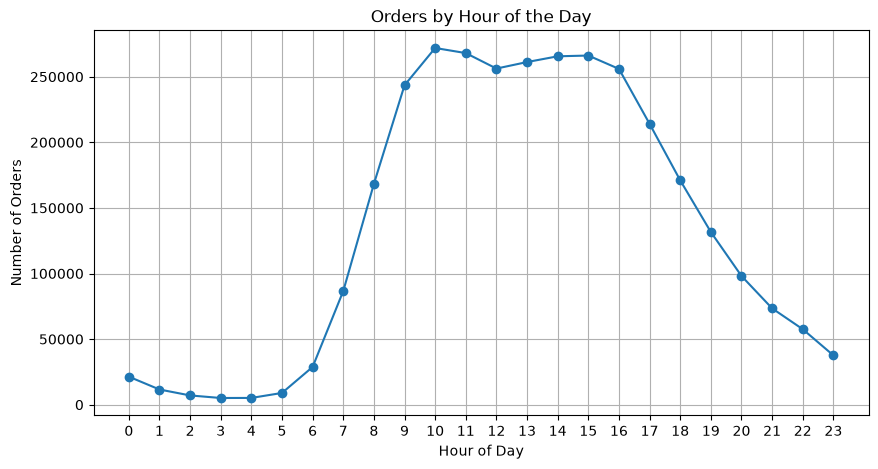

In [26]:
orders_by_hour = (instacart_df.groupby("order_hour_of_day")["order_id"].nunique())
display(orders_by_hour)



plt.figure(figsize=(10,5))

plt.plot(orders_by_hour.index, orders_by_hour.values, marker="o")

plt.title("Orders by Hour of the Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")

plt.xticks(range(24))

plt.grid(True)

plt.show()

#### Observation

- Customer ordering activity is lowest during the early morning hours (12 AM–5 AM), indicating minimal shopping activity overnight.
- Order volume begins increasing rapidly from **6 AM**, reflecting the start of daily shopping activity.
- Customer orders peak between **10 AM and 3 PM**, with the highest number of orders recorded at **3 PM (266,132 orders)**.
- After **4 PM**, order volume gradually declines, with a noticeable drop during the late evening hours.
- The results indicate that customers primarily place grocery orders during daytime hours, particularly from late morning to mid-afternoon.